# TARDIS — Météo-France Weather Data: Cleaning & Exploration

This notebook prepares two Météo-France daily observation datasets for downstream modelling, then explores key meteorological patterns.

---

## Datasets

### `RR-T-Vent` — precipitation, temperature, wind
Each row = **one day of measurements at one station**:
- **Station** — `NUM_POSTE` (code), `NOM_USUEL` (name), `LAT`, `LON`, `ALTI`
- **Date** — `AAAAMMJJ` (integer YYYYMMDD)
- **Precipitation** — `RR` (mm/day), `DRR` (duration)
- **Temperature** — `TN` (min), `TX` (max), `TM` (mean), `TAMPLI` (diurnal range), `TNSOL`, `TN50`
- **Wind** — `FFM` (mean), `FF2M`, gusts `FXY`/`FXI`/`FXI2`/`FXI3S`, directions `DXY`/`DXI`
- Each variable has a matching quality flag (`Q*`): **0** = suspicious, **1** = valid, **9** = unchecked

### `autres-paramètres` — complementary sensor data
- **Pressure** — `PMERM` (mean sea-level), `PMERMIN`
- **Radiation & sunshine** — `GLOT`, `DIFT`, `DIRT`, `INFRART`, `UV`, `INST` (hours), `SIGMA`
- **Humidity** — `UN` (min %), `UX` (max %), `UM` (mean %), `DHUMI40`, `DHUMI80`
- **Snow & ice** — `HNEIGEF`, `NEIGETOTX`, `NEIGETOT06`
- **Weather phenomena** (binary flags) — `NEIG` (snow), `BROU` (fog), `ORAG` (thunderstorm), `GRELE` (hail), `VERGLAS` (ice), `GELEE` (frost), `ROSEE` (dew), `SOLNEIGE` (snow on ground)

Source: [data.gouv.fr — Données climatologiques de base quotidiennes](https://www.data.gouv.fr/fr/datasets/donnees-climatologiques-de-base-quotidiennes/)

---

## How this notebook works

All data cleaning is handled automatically by `Pipeline` (streaming, one département at a time — never more than ~500 MB RAM). The notebook:
1. Runs the pipeline once and saves the result to `data/processed/meteo/cleaned_meteo_dataset.csv`
2. Loads that file on every subsequent run (skips the pipeline)
3. Applies a **global column filter** — drops any column below 60% completeness
4. Runs a **quality audit** to document what the pipeline produced
5. Explores the data through **14 visualisations**

| Section | What happens |
|---------|-------------|
| **1 — Imports** | Load libraries and internal modules |
| **2 — Pipeline + load** | Run cleaning (if needed) and load the output CSV |
| **2.1 — Column filter** | Drop columns with < 60% non-null values globally |
| **3 — Audit** | Completeness, distributions, outliers, validity checks |
| **4 — Export** | Save the audit report to CSV |
| **5 — EDA (M1–M14)** | Visualise temperature, precipitation, wind, phenomena, trends, geography |
| **6 — Pre-conclusion (P1–P6)** | Station ranking, year × month patterns, seasonal summaries |

> **Run cells top to bottom.** Each section depends on the result of the previous one.

### 1 — Imports

```
pandas      → dataframe manipulation and CSV I/O
matplotlib  → base plotting engine
seaborn     → statistical visualisations (box plots, heatmaps, KDE)
huggingface → automatic data download from HuggingFace Datasets
```

Internal modules live under `scripts/cleaning/meteo/` and are imported as `pkg.*`:

| Module | Role |
|--------|------|
| `pkg.loading` | Reads raw CSV index files, loads and concatenates station files |
| `pkg.merging` | Joins `RR-T-Vent` and `autres-paramètres` on `NUM_POSTE + AAAAMMJJ` |
| `pkg.cleaning` | All cleaning transforms: quality flags, dedup, NaN handling, type fixes, interpolation |
| `pkg.features` | Derives new columns: year/month/season, temperature amplitude, wind & precipitation categories |
| `pkg.audit` | Computes and records data quality metrics |
| `pkg.visualization.cleaning_plots` | Charts related to the cleaning pipeline |
| `pkg.visualization.eda_plots` | Exploratory data analysis charts |

> Météo-France quality codes: **1** = valid, **0** = suspicious (→ set to NaN), **9** = unchecked (→ left as-is).

In [96]:
import os
import gc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from pathlib import Path
from huggingface_hub import snapshot_download

**Project modules** — one alias per pipeline component, all living under `scripts/cleaning/meteo/`.

In [97]:
from scripts.cleaning import meteo as pkg

audit    = pkg.audit
cleaning = pkg.cleaning
features = pkg.features
loading  = pkg.loading
merging  = pkg.merging
cplots   = pkg.visualization.cleaning_plots
eplots   = pkg.visualization.eda_plots

### Data download

The raw data is hosted on [HuggingFace Datasets](https://huggingface.co/datasets/sacha-lma/Tardis-data). The block below downloads it automatically into `data/` if the folder does not yet exist. If the data is already present locally, the download is skipped.

> The repository contains the meteorological CSV files under `data/raw/meteo/`, together with two index files — `meteo_raw_vent_source_files.txt` and `meteo_raw_parametres_source_files.txt` — that list one filename per line. These index files are the inputs to the loading functions.

In [98]:
if not Path("data").exists():
    snapshot_download(
        repo_id="sacha-lma/Tardis-data",
        repo_type="dataset",
        local_dir="data",
    )

### Audit report — initialisation

`AuditReport` accumulates quality metrics throughout the notebook. Each cleaning and audit step appends `(metric, value, category, reason)` entries to it. The full set is written to `cleaning_meteo_report.csv` at section 4.

Think of it as a structured log: every number you see in the audit section is also persisted to disk and can be compared across pipeline runs.

In [99]:
report = audit.AuditReport()

In [100]:
OUTPUT   = "data/processed/meteo/cleaned_meteo_dataset.csv"
RPT_PATH = "data/processed/audit/cleaning_meteo_report.csv"

if not os.path.exists(OUTPUT):
    from scripts.cleaning.meteo.pipeline import Pipeline
    Pipeline(
        data_vent_path="data/raw/meteo/meteo_raw_vent_source_files.txt",
        data_parameter_path="data/raw/meteo/meteo_raw_parametres_source_files.txt",
        output_path=OUTPUT,
        report_path=RPT_PATH,
    ).run()
else:
    print(f"Output already exists — loading directly: {OUTPUT}")

Output already exists — loading directly: data/processed/meteo/cleaned_meteo_dataset.csv


**Load the cleaned dataset**

`pd.read_csv` reads everything back as plain strings. Three columns need explicit re-casting after load:

- **`date`** → `datetime64` so `.dt` accessors work in the EDA plots
- **`year`** → `Int16` (nullable 16-bit integer, ~4× smaller than default `int64`)
- **`month`** → `Int8` (nullable 8-bit integer)

In [101]:
df = pd.read_csv(OUTPUT, low_memory=False)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
for _col, _dtype in [("year", "Int16"), ("month", "Int8")]:
    if _col in df.columns:
        df[_col] = df[_col].astype(_dtype)

_original_rows = len(df)
_original_cols = df.shape[1]
print(f"Loaded  : {_original_rows:,} rows × {_original_cols} columns")
print(f"date    : {df['date'].dtype}")
print(f"Columns : {df.columns.tolist()}")

Loaded  : 2,218,180 rows × 75 columns
date    : datetime64[us]
Columns : ['NUM_POSTE', 'NOM_USUEL', 'LAT', 'LON', 'ALTI', 'AAAAMMJJ', 'RR', 'TN', 'HTN', 'TX', 'HTX', 'TM', 'TNTXM', 'TAMPLI', 'TNSOL', 'TN50', 'DG', 'FFM', 'FF2M', 'FXY', 'DXY', 'HXY', 'FXI', 'DXI', 'HXI', 'FXI2', 'DXI2', 'HXI2', 'FXI3S', 'DXI3S', 'HXI3S', 'DRR', 'STATUS_FXI3S', 'STATUS_DXI3S', 'DHUMEC', 'PMERM', 'PMERMIN', 'INST', 'GLOT', 'DIFT', 'DIRT', 'INFRART', 'UV', 'UV_INDICEX', 'SIGMA', 'UN', 'HUN', 'UX', 'HUX', 'UM', 'DHUMI40', 'DHUMI80', 'TSVM', 'ETPMON', 'ETPGRILLE', 'ECOULEMENTM', 'HNEIGEF', 'NEIGETOTX', 'NEIGETOT06', 'NEIG', 'BROU', 'ORAG', 'GRESIL', 'GRELE', 'ROSEE', 'VERGLAS', 'SOLNEIGE', 'GELEE', 'date', 'year', 'month', 'season', 'temp_amplitude', 'wind_category', 'precip_category']


### 2.1 — Column completeness filter

Any column where **fewer than 60% of values are present** is dropped before analysis begins.

**Why:** in a national weather dataset built from ~1 500 stations with different sensor equipment, some columns are structurally sparse — not because of data quality issues, but because most stations simply don't have that sensor. Keeping those columns would inflate the NaN count, distort completeness statistics, and add noise to downstream models with very little signal.

| Completeness | Decision |
|-------------|---------|
| ≥ 60% | **Retained** — enough observations across the network to be useful |
| < 60% | **Dropped** — too sparse; the majority of station-days have no value at all |

**Always protected** (never dropped regardless of completeness): `NUM_POSTE`, `NOM_USUEL`, `LAT`, `LON`, `ALTI`, `date`, `year`, `month`, `season`.

The chart below shows the completeness of every column before the filter is applied. Columns in **red** are dropped; columns in **green** are kept.

In [102]:
THRESHOLD = 0.05
completeness_before = df.notna().mean().sort_values()

df, dropped_cols = cleaning.drop_sparse_columns(df, threshold=THRESHOLD)

print(f"Columns retained : {df.shape[1]}")
print(f"Columns dropped  : {len(dropped_cols)}")
if dropped_cols:
    print(f"  → {', '.join(dropped_cols)}")

drop_sparse_columns: removed 25 column(s) (< 5% complete)
  Dropped: TNSOL, TN50, FF2M, FXI2, DXI2, HXI2…
Columns retained : 50
Columns dropped  : 25
  → TNSOL, TN50, FF2M, FXI2, DXI2, HXI2, DRR, DHUMEC, PMERM, PMERMIN, INST, GLOT, DIFT, DIRT, INFRART, UV, UV_INDICEX, SIGMA, ETPMON, ECOULEMENTM, GRESIL, ROSEE, VERGLAS, SOLNEIGE, GELEE


**Completeness chart** — each bar shows the fraction of non-null values for one column. The dashed line is the 60% threshold; bars in red were removed, bars in green are kept.

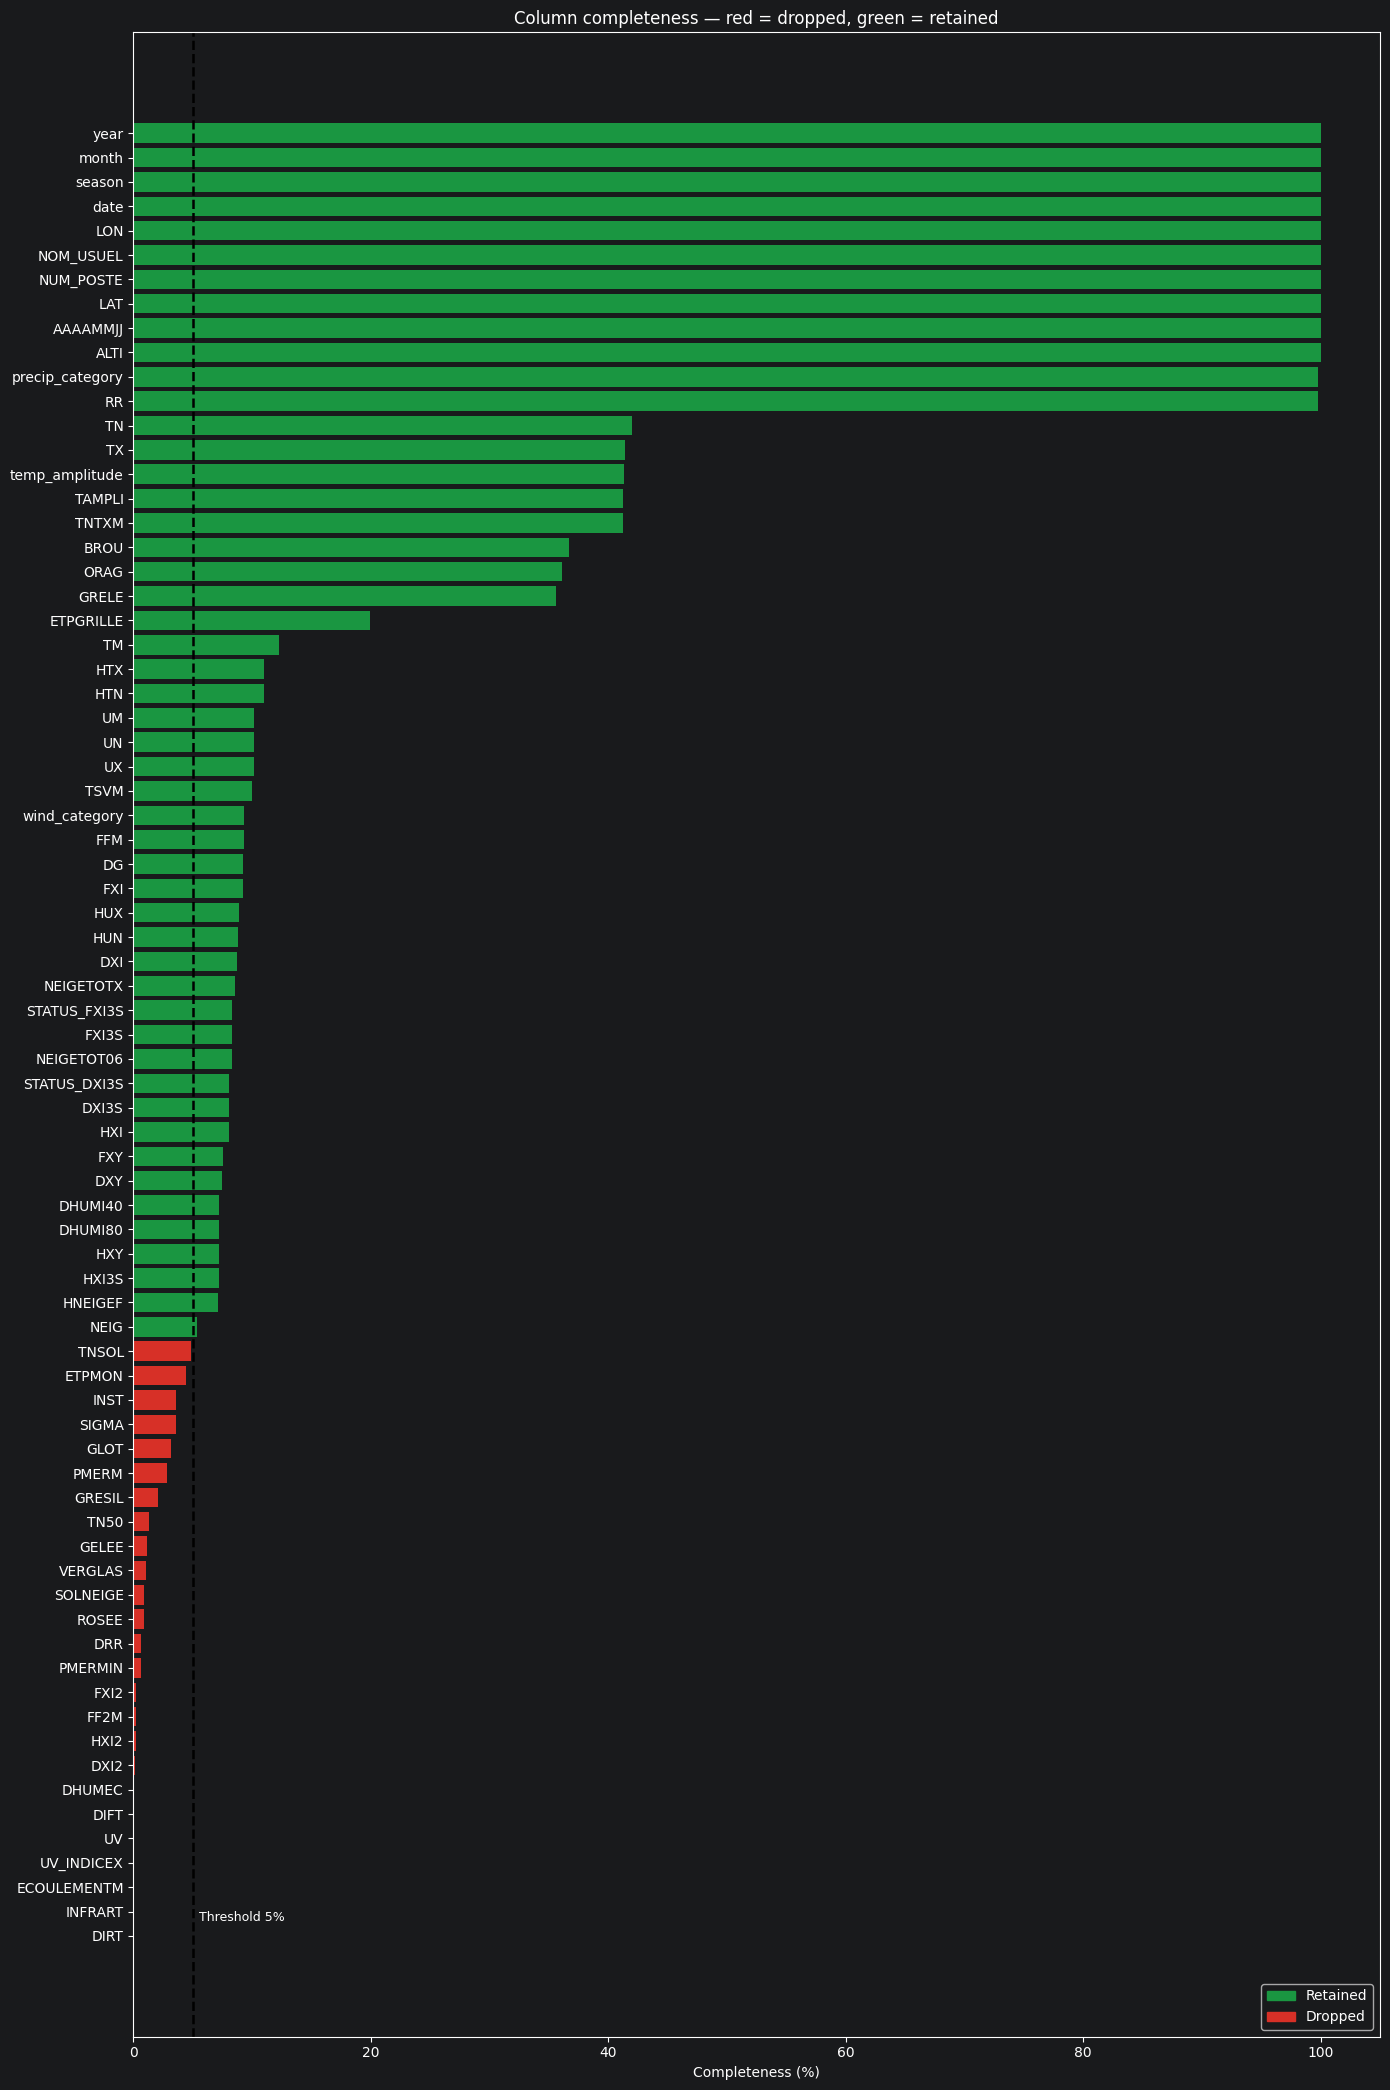

In [103]:
fig, ax = plt.subplots(figsize=(14, max(6, len(completeness_before) * 0.28)))
colors = ["#d73027" if col in dropped_cols else "#1a9641"
          for col in completeness_before.index]
ax.barh(completeness_before.index, completeness_before.values * 100, color=colors)
ax.axvline(THRESHOLD * 100, color="black", linewidth=1.8, linestyle="--")
ax.text(THRESHOLD * 100 + 0.5, 0.5, f"Threshold {THRESHOLD:.0%}", va="bottom", fontsize=9)
ax.set_xlabel("Completeness (%)")
ax.set_title("Column completeness — red = dropped, green = retained")
ax.legend(handles=[
    mpatches.Patch(color="#1a9641", label="Retained"),
    mpatches.Patch(color="#d73027", label="Dropped"),
], loc="lower right")
plt.tight_layout()
plt.show()

### 3 — Data quality audit

Five checks that measure the quality of the cleaned dataset. **None of these modify the data** — they document it. All results feed into the audit report exported at section 4.

| Sub-section | Question answered |
|-------------|-------------------|
| **3.1 Completeness** | What fraction of cells actually have a value? |
| **3.2 Distributions** | Do the numerical ranges make physical sense? |
| **3.3 Outlier rates** | What fraction of values are statistical extremes (|z| > 3)? |
| **3.4 Validity checks** | Do hard physical rules hold everywhere? (TN ≤ TX, RR ≥ 0, …) |

> These numbers are evidence that the pipeline worked correctly. A failed validity check (0) means a cleaning step didn't fully correct an issue and warrants investigation.

#### 3.1 — Completeness

**What it measures:** the fraction of non-null cells in the retained dataset, overall and per column.

Note: columns below 60% completeness were already removed in section 2.1, so all columns shown here have passed the threshold. The five least-complete columns indicate which sensors have the lowest deployment rate across stations — structural missingness, not a data quality problem.

In [104]:
audit.check_completeness(df, report)

Overall completeness : 35.74%  (39,638,327 / 110,909,000 cells non-null)

Least complete columns:
    5.3%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░  NEIG
    7.1%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░  HNEIGEF
    7.2%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░  HXI3S
    7.2%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░  HXY
    7.2%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░  DHUMI80

Most complete columns:
  100.0%  LON
  100.0%  date
  100.0%  year
  100.0%  season
  100.0%  month


0.3574

#### 3.2 — Numeric distributions

**What it measures:** count, mean, std, quartiles, min, and max for the most important meteorological columns.

This verifies that cleaning did not distort natural distributions. Key things to check:
- `TN` should always be less than `TX` (enforced by the pipeline's consistency fix)
- `RR` should have no negative values (physically impossible)
- `PMERM` should sit in the range 950–1060 hPa (normal atmospheric pressure range)

In [105]:
audit.check_distributions(df, report)

                      n    mean     std    min   p25  median   p75    max
column                                                                   
RR              2212345   2.656   6.085   0.00   0.0     0.0   2.5  180.0
TN               931434   5.900   6.240 -32.10   1.3     6.0  10.6   26.1
TX               917831  15.275   8.364 -14.70   9.0    15.1  21.6   43.0
TM               271276  10.760   6.959 -18.60   5.6    10.8  16.1   32.6
TAMPLI           915467   9.350   4.781   0.00   5.5     8.9  12.9   31.0
FFM              207339   3.017   1.820   0.00   1.7     2.7   4.0   16.6
FXY              166447   5.993   2.578   0.00   4.0     5.7   7.4   28.0
UN               224429  59.198  18.632   7.00  45.0    58.0  73.0  100.0
UX               224382  95.231   5.769  32.00  94.0    97.0  99.0  100.0
temp_amplitude   916953   9.351   4.780  -1.75   5.5     8.9  12.9   31.0


,n,mean,std,min,p25,median,p75,max
column,,,,,,,,
RR,2212345,2.656,6.085,0.00,0.0,0.0,2.5,180.0
TN,931434,5.900,6.240,-32.10,1.3,6.0,10.6,26.1
TX,917831,15.275,8.364,-14.70,9.0,15.1,21.6,43.0
TM,271276,10.760,6.959,-18.60,5.6,10.8,16.1,32.6
TAMPLI,915467,9.350,4.781,0.00,5.5,8.9,12.9,31.0
FFM,207339,3.017,1.820,0.00,1.7,2.7,4.0,16.6
FXY,166447,5.993,2.578,0.00,4.0,5.7,7.4,28.0
UN,224429,59.198,18.632,7.00,45.0,58.0,73.0,100.0
UX,224382,95.231,5.769,32.00,94.0,97.0,99.0,100.0


#### 3.3 — Outlier rates

**What it measures:** for each numeric column, the fraction of values more than **3 standard deviations** from the column mean (|z-score| > 3).

A high outlier rate is not always bad — extreme weather events (storms, cold snaps, heat waves) are real and should remain in the data. But a rate above ~5% on a non-skewed variable is suspicious and may indicate sensor faults that the quality flag system missed.

In [106]:
outlier_rows = audit.check_outliers(df, report)

Column                                   N outliers     Rate
─────────────────────────────────────────────────────────────────
ALTI                                         72,123   3.25%  █████████
BROU                                         58,626   2.64%  ███████
RR                                           50,499   2.28%  ██████
ORAG                                         35,001   1.58%  ████
HUN                                           8,808   0.40%  █
DG                                            8,436   0.38%  █
HTX                                           6,872   0.31%  
DHUMI40                                       5,455   0.25%  
UX                                            4,950   0.22%  
NEIGETOTX                                     4,508   0.20%  
NEIGETOT06                                    4,501   0.20%  
GRELE                                         3,686   0.17%  
TN                                            2,894   0.13%  
HNEIGEF                                

Outlier rates per column — the bar chart makes high-rate columns immediately visible. The red dashed line marks the 5% warning threshold.

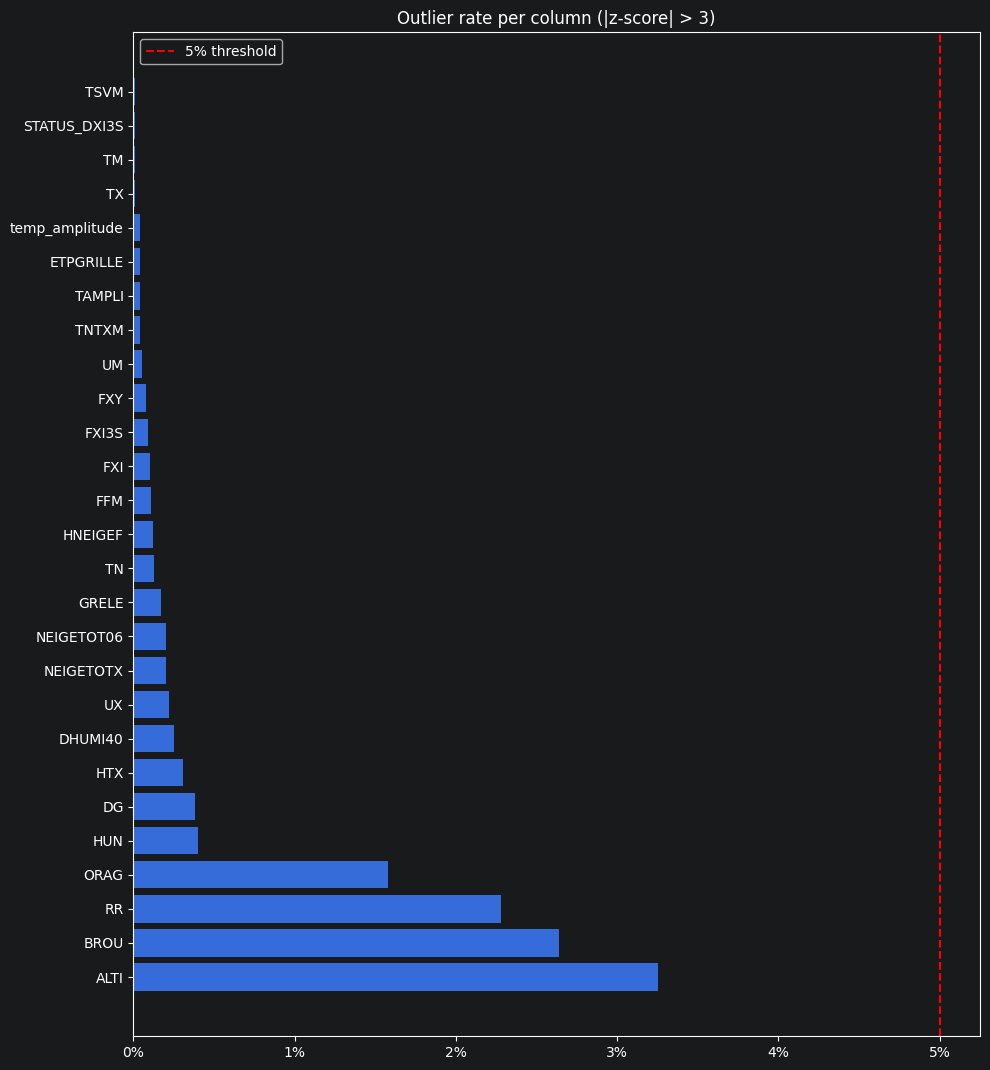

In [107]:
cplots.plot_outlier_rates(outlier_rows)

#### 3.4 — Validity checks

**What it measures:** binary assertions on physical and logical invariants that must hold after a correct cleaning pipeline.

| Check | Why it matters |
|-------|----------------|
| `tn_le_tx` | Minimum temperature ≤ maximum temperature — a basic physical law |
| `rr_non_negative` | Precipitation cannot be negative |
| `ffm/fxy/fxi_non_negative` | Wind speed cannot be negative |
| `un/ux/um_in_0_100` | Relative humidity is a percentage — must be 0–100 |
| `tm_range_sane` | Mean temperature within −60 °C to +60 °C |
| `pmerm_range_sane` | Sea-level pressure within 900–1100 hPa |
| `date_range_sane` | All dates between 1950 and 2026 |
| `no_fully_null_rows` | No row where every single value is missing |

A result of **1 = pass, 0 = fail**. All 12 checks should pass after a clean pipeline run.

In [108]:
checks = audit.check_validity(df, report)

Validity checks:
  ✓ tn_le_tx
  ✓ rr_non_negative
  ✓ ffm_non_negative
  ✓ fxy_non_negative
  ✓ fxi_non_negative
  ✓ un_in_0_100
  ✓ ux_in_0_100
  ✓ um_in_0_100
  ✓ tm_range_sane
  ✓ date_range_sane
  ✓ no_fully_null_rows

11/11 checks passed


Each check is shown as a green tick or red cross. All 12 must pass for the dataset to be considered clean.

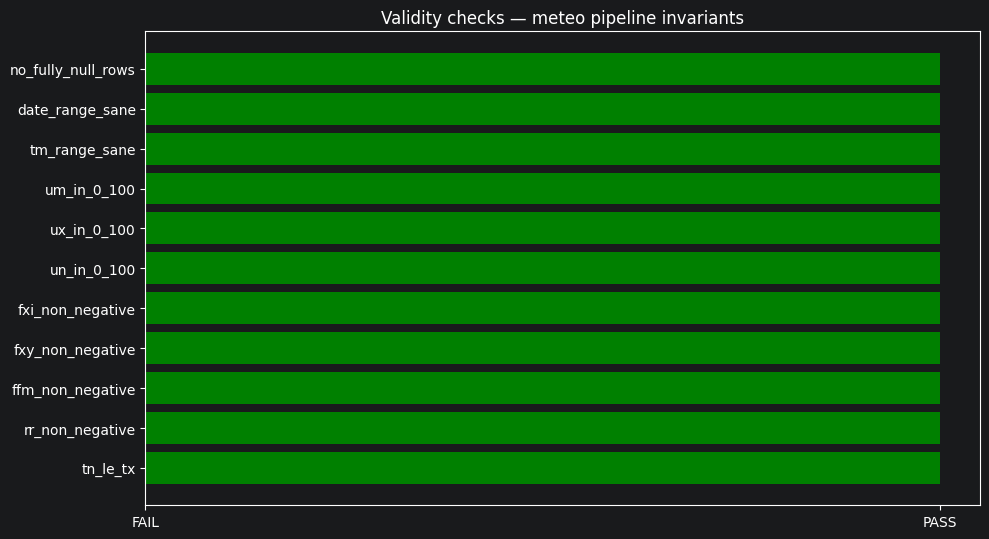

In [109]:
cplots.plot_validity_checks(checks)

### 4 — Export — audit report

Saves all audit metrics accumulated during section 3 to `cleaning_meteo_report.csv`. The file is a flat list of `(metric, value, category, reason)` rows and can be compared across pipeline runs to detect regressions in data quality.

In [110]:
report.record_final_state(df, original_rows=_original_rows)
os.makedirs(os.path.dirname(os.path.abspath(RPT_PATH)), exist_ok=True)
report.export(RPT_PATH)

Report saved: 189 entries → data/processed/audit/cleaning_meteo_report.csv
category
numeric_distribution       80
completeness_per_column    50
outlier_analysis           41
validity_checks            13
final_state                 4
quality_score               1


### 5 — Exploratory Data Analysis (EDA)

The dataset is now cleaned, filtered, and audited. This section visualises the key meteorological patterns across all stations and the full available time range.

**Why this matters for TARDIS:** the goal is to link weather conditions to train punctuality. To build that link, we first need to understand what the weather data looks like — its distributions, seasonal structure, geographic patterns, and long-term trends. These plots establish the baseline.

Plots are grouped into two parts:
- **M1–M14** — core distributions and trends (temperature, precipitation, wind, phenomena, sunshine, humidity, geography)
- **P1–P6** — pre-conclusion summaries connecting patterns to the modelling goal

**M1 — Daily temperature distributions (TN, TM, TX)**

Histograms with KDE overlay for minimum (`TN`), mean (`TM`), and maximum (`TX`) daily temperature across all stations and dates.

**What to look for:** three overlapping bell-shaped distributions shifted right relative to each other (TN < TM < TX), with long cold tails in winter. A bimodal shape would suggest a mix of very different climatic zones.

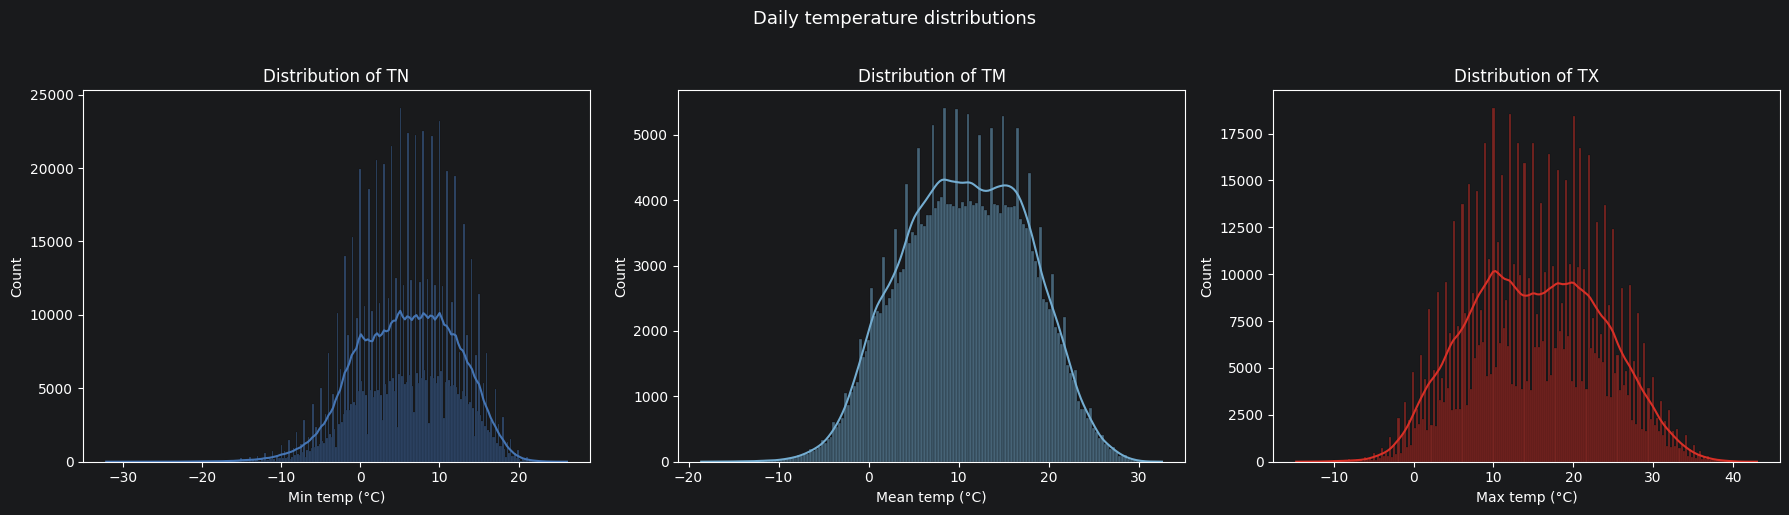

In [111]:
eplots.plot_temperature_distribution(df)

**M2 — Temperature by season (violin plot)**

Distribution of daily mean temperature (`TM`) across the four seasons.

**What to look for:** a clear ordering winter < spring/autumn < summer, with summer having a narrower spread (stable heat) and spring/autumn wider (rapidly changing conditions). Wide summer tails can indicate heat waves — relevant to rail buckling risk.

/home/pochy/projects/tardis/scripts/cleaning/meteo/visualization/eda_plots.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="season", y="TM", data=df,


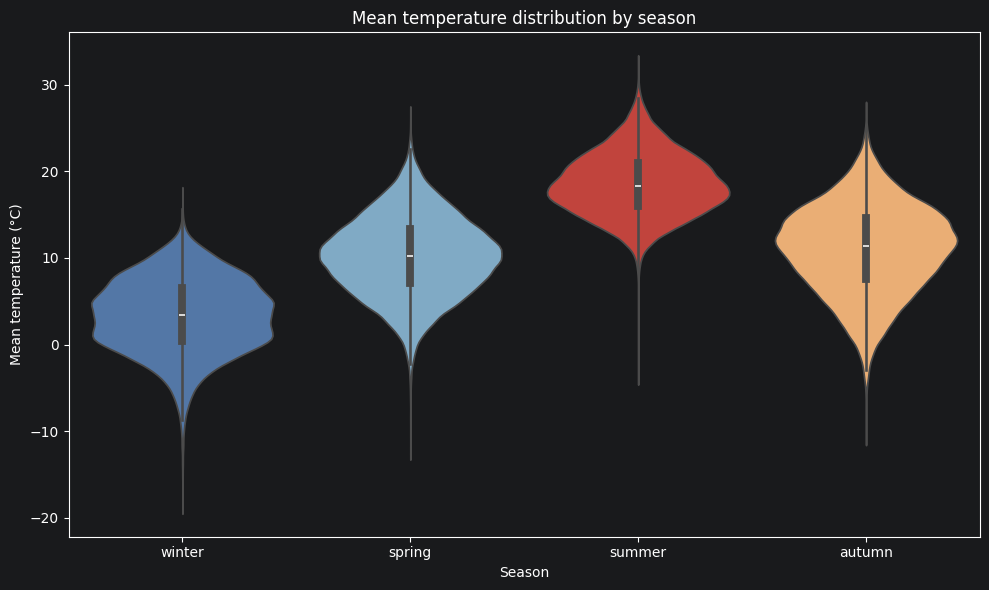

In [112]:
eplots.plot_seasonal_temperature(df)

**M3 — Precipitation distribution and category breakdown**

Left: histogram of daily rainfall for rainy days only (RR > 0) on a log scale, revealing the heavy right tail. Right: pie chart of precipitation categories across all station-days (including dry days).

**What to look for:** most rainy days are light (< 5 mm), but heavy events (> 20 mm) are the ones most likely to cause flooding and train disruptions. The log scale makes the tail visible.

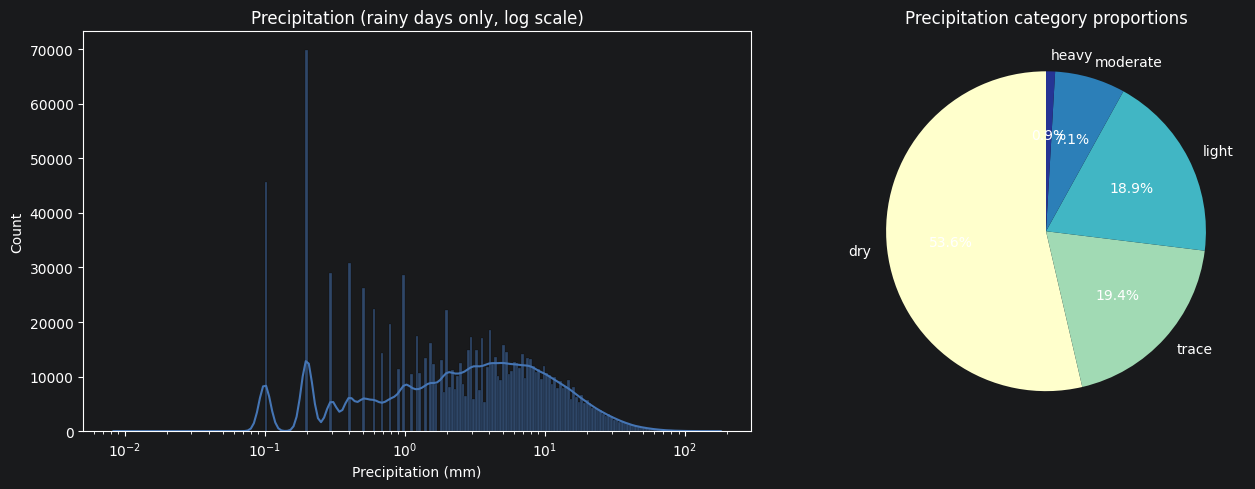

In [113]:
eplots.plot_precipitation_distribution(df)

**M4 — Wind speed distribution and category counts**

Left: histogram of daily mean wind speed (`FFM`, m/s). Right: count of station-days per wind category (calm → storm).

**What to look for:** the majority of days should fall in "calm" to "light" range, with an exponentially decaying tail. Days in the "storm" category are rare but strongly associated with speed restrictions and overhead line damage on rail networks.

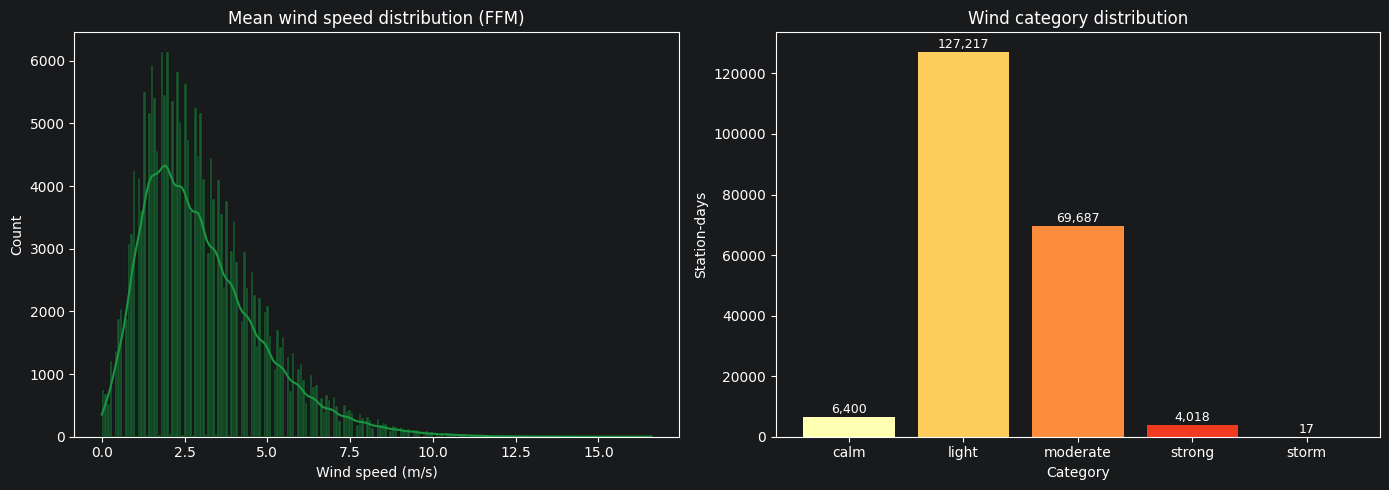

In [114]:
eplots.plot_wind_distribution(df)

**M5 — Monthly mean temperature trend over time**

Mean temperature (`TM`) averaged across all active stations, plotted month by month from the earliest available year to the latest. The 12-month rolling mean smooths seasonal noise; the dashed line shows the overall average.

**What to look for:** a long-term upward trend (climate warming), seasonal oscillations, and anomalous periods (heat waves, cold snaps). This is the primary signal for the TARDIS temporal modelling.

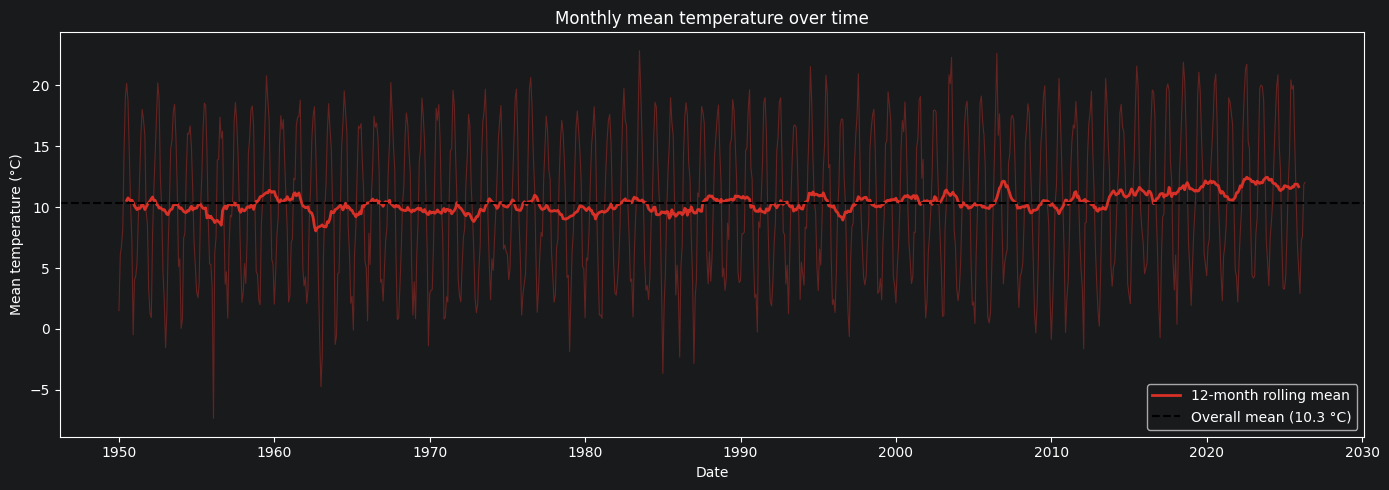

In [115]:
eplots.plot_monthly_temperature_trend(df)

**M6 — Correlation matrix**

Pearson correlations between key meteorological features, shown as a lower-triangle heatmap (red = positive correlation, blue = negative).

**What to look for:**
- `TN / TM / TX` strongly correlated with each other — as expected, they all measure temperature
- `temp_amplitude` and `INST` positively correlated — clear days produce both more sunshine and a wider day/night temperature swing
- `RR` and humidity columns — heavier rainfall correlates with higher humidity
- `FFM / FXY / FXI` — mean and gust wind speeds move together

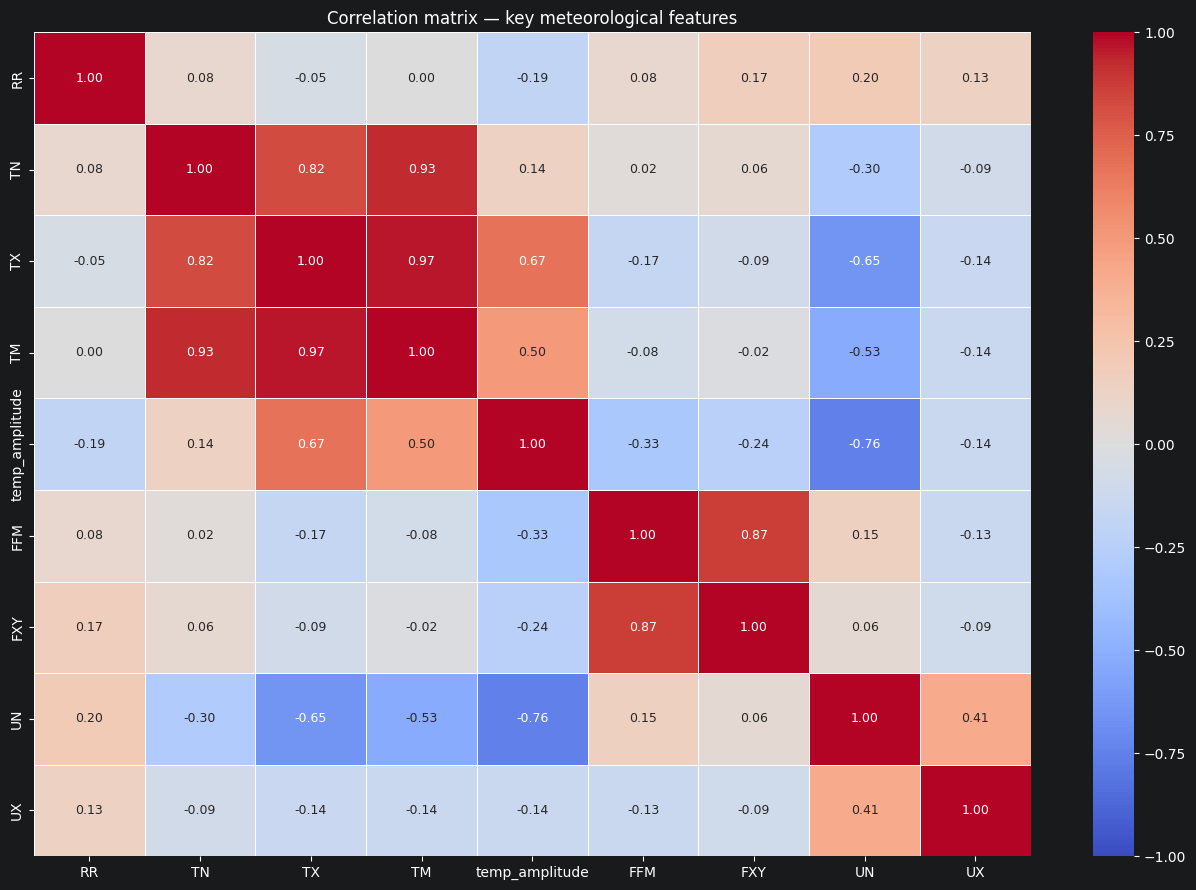

In [116]:
eplots.plot_correlation_matrix(df)

**M7 — Annual temperature anomaly**

Mean temperature per year relative to the 1961–1990 climatological baseline. Red bars = years warmer than the reference; blue = cooler. The 10-year rolling mean reveals the long-term warming trend beneath year-to-year noise.

**What to look for:** an increasing dominance of red bars from the 1980s onward — the observational fingerprint of climate change in the French station network.

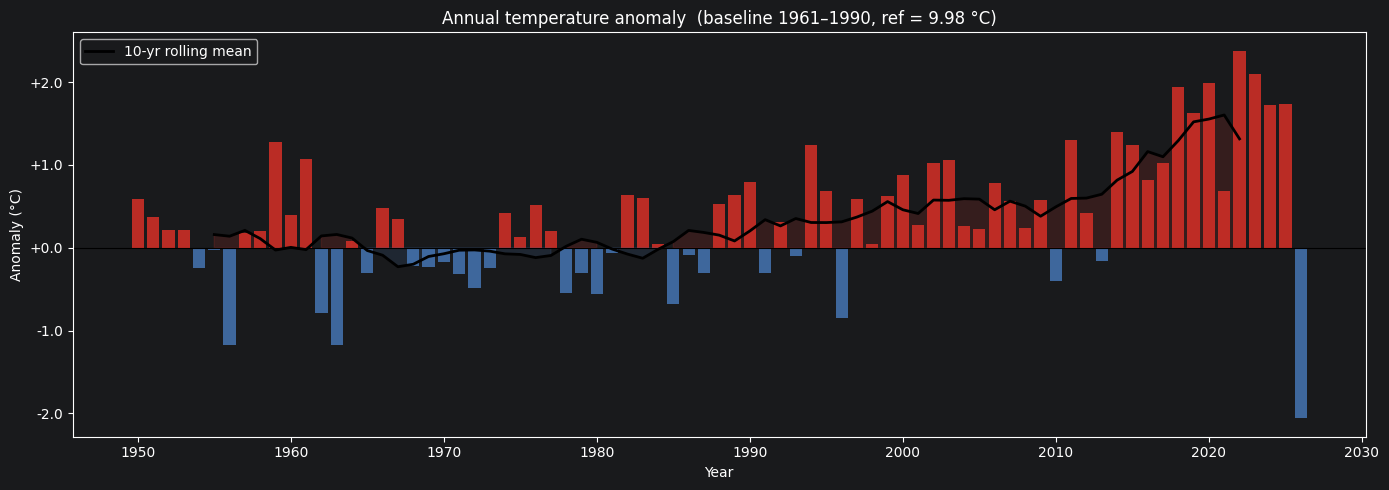

In [117]:
eplots.plot_temperature_anomaly(df)

**M8 — Station network geography**

Each dot is one weather station placed at its actual latitude/longitude. Colour encodes mean temperature (blue = cold, red = warm); dot size is proportional to the number of records (larger = more data).

**What to look for:** spatial gaps in the network (areas with few stations), the north–south temperature gradient, and whether the densest station clusters align with major rail corridors.

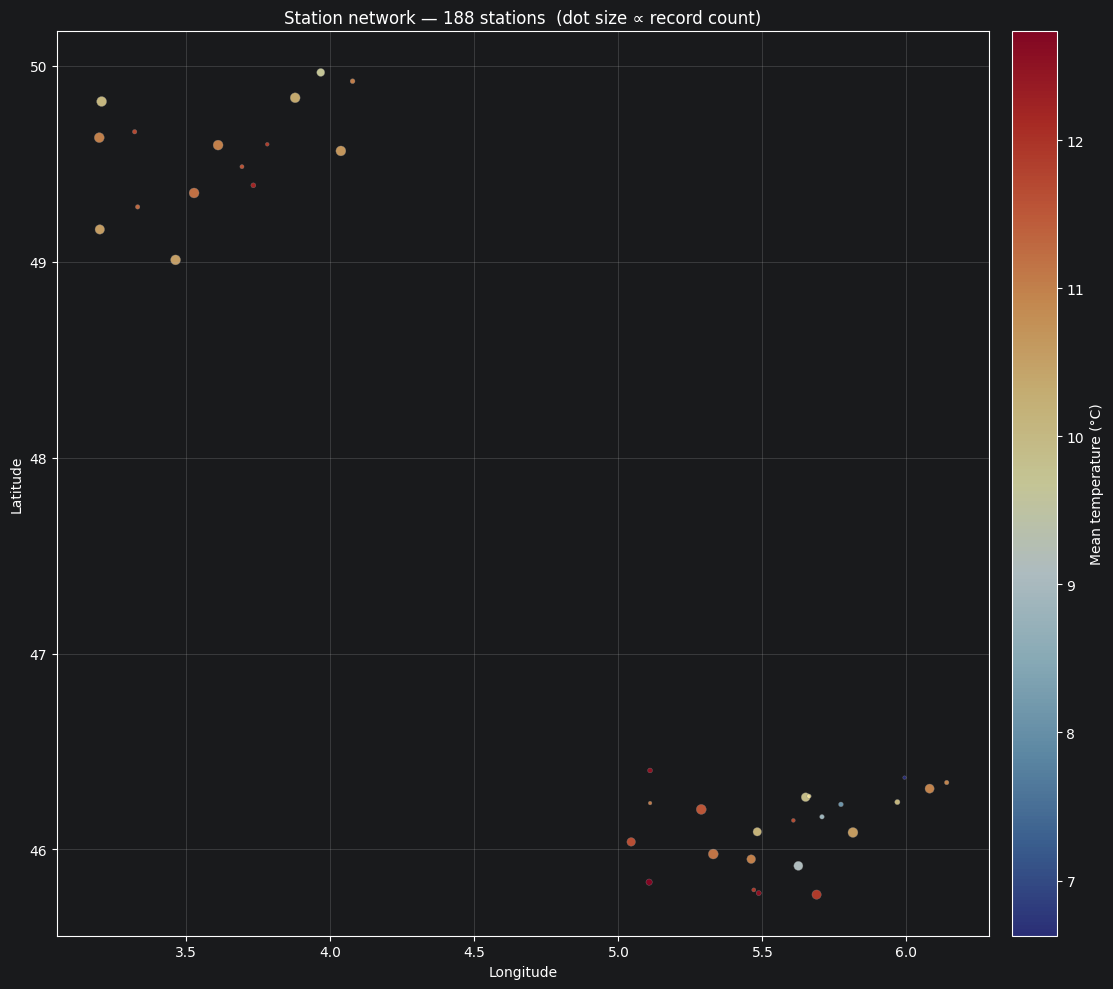

In [118]:
eplots.plot_station_map(df)

**M9 — Weather phenomena by month**

Monthly count of station-days with each binary weather phenomenon: snowfall (`NEIG`), thunderstorms (`ORAG`), fog (`BROU`), frost (`GELEE`), and ice on the ground (`VERGLAS`).

**What to look for:** strong seasonal peaks — snow and frost in December–February, thunderstorms in June–August, fog peaking in October–November. These are the phenomena most directly linked to train delays in the TARDIS dataset.

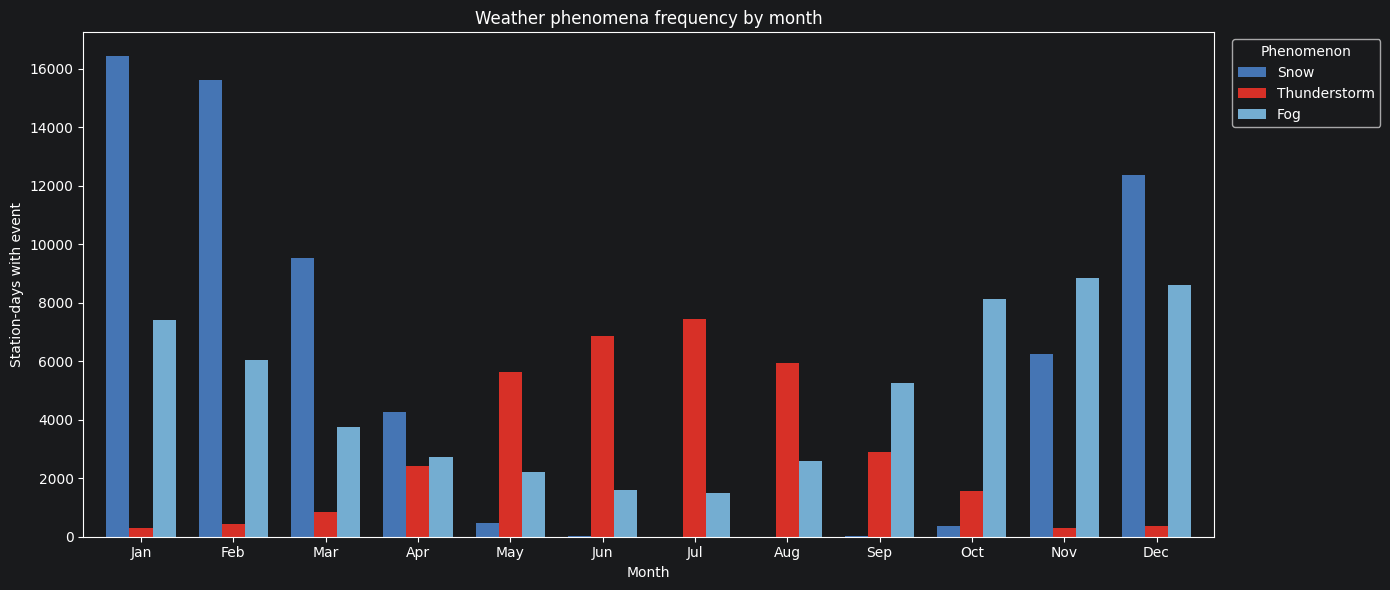

In [119]:
eplots.plot_weather_events_by_month(df)

**M10 — Precipitation by season**

Left: violin plot (log scale) of daily precipitation intensity on rainy days, by season. Right: percentage of station-days with any rainfall per season.

**What to look for:** autumn and winter show more frequent rain; summer is drier but can produce more intense convective events. Both frequency and intensity matter for flood risk on rail infrastructure.

/home/pochy/projects/tardis/scripts/cleaning/meteo/visualization/eda_plots.py:340: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="season", y="RR", data=rainy, order=_SEASON_ORDER,


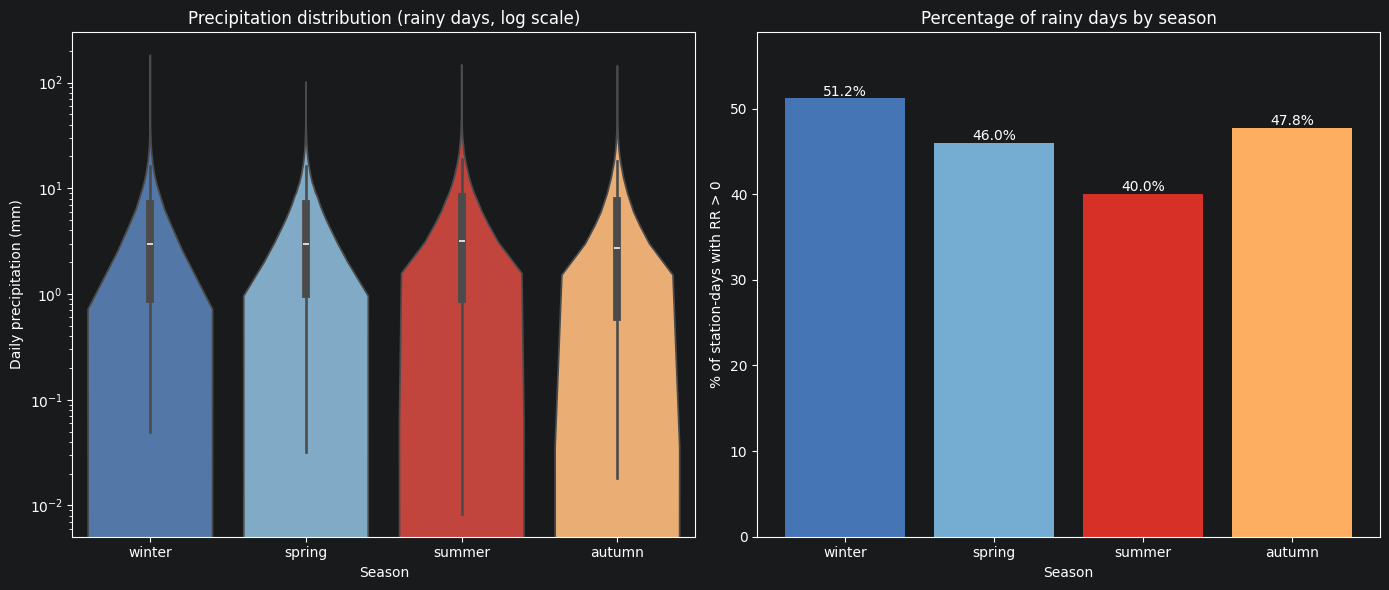

In [120]:
eplots.plot_seasonal_precipitation(df)

**M11 — Sunshine duration (`INST`)**

Left: distribution of daily sunshine hours across all stations and years. Right: monthly boxplot — how much sunshine does each calendar month get on average?

**What to look for:** a strong July peak and December trough. Wide interquartile boxes in summer reflect the north–south gradient — southern Mediterranean stations get significantly more sun than northern ones.

In [86]:
eplots.plot_sunshine_overview(df)

[plot_sunshine_overview] INST (sunshine hours) column missing.


**M12 — Temperature vs precipitation on rainy days**

Scatter of 50 000 randomly sampled rainy station-days (RR > 0), coloured by season. Y-axis is on a log scale to make the full range of precipitation intensity visible.

**What to look for:** winter points cluster cold-left / low-intensity; summer points extend warmer-right and occasionally spike high (intense convective storms). The spread reveals which season produces the most extreme single-day rainfall events.

In [87]:
eplots.plot_temp_precip_scatter(df)

[plot_temp_precip_scatter] TM, RR, or season column missing.


**M13 — Long-term trends in temperature, precipitation, and wind**

Three-panel chart of annual aggregates from the earliest year to the latest. Each panel shows the raw annual value (thin line), a 10-year rolling mean (thick), and a linear trend (dashed).

**What to look for:** a statistically significant upward slope in temperature; high interannual variability in precipitation with no clear long-term trend; a possible slight decrease in mean wind speed ("wind stilling" observed across Europe).

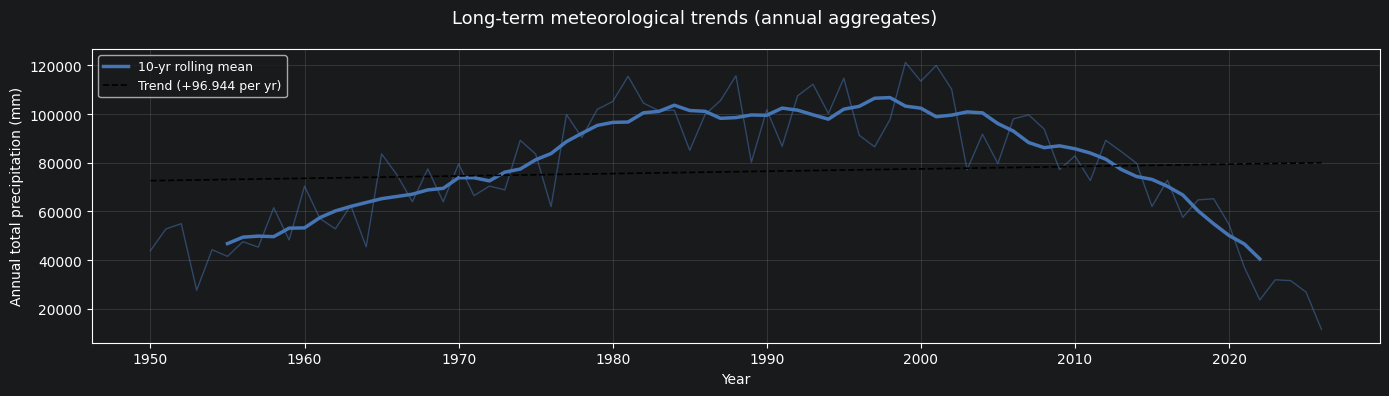

In [88]:
eplots.plot_long_term_trends(df)

**M14 — Relative humidity**

Left: KDE distributions for minimum (`UN`), mean (`UM`), and maximum (`UX`) daily relative humidity across all stations. Right: seasonal boxplot of mean humidity (`UM`).

**What to look for:** `UX` clusters near 100% (nights are almost always saturated at dew point); `UN` is more spread and often drops below 50% on dry sunny afternoons. Autumn and winter show systematically higher humidity than summer.

In [89]:
eplots.plot_humidity_overview(df)

[plot_humidity_overview] No humidity columns (UN, UM, UX) found.


---

## 6 — Pre-conclusion: patterns relevant to train delay modelling

This section focuses on patterns that are directly relevant to the TARDIS goal: **understanding which weather conditions are associated with train disruptions**.

Each visualisation is framed as a question the model will need to answer.

| Plot | Question |
|------|---------|
| **P1** | Which stations experience the most extreme heat — and are they on major rail corridors? |
| **P2** | Is there a consistent Year × Month temperature pattern, or do anomalous years stand out? |
| **P3** | How does monthly precipitation volume evolve over time? Are wet months becoming more extreme? |
| **P4** | Does wind speed vary enough between seasons to explain seasonal delay patterns? |
| **P5** | Which stations have the most complete records — and are they well-distributed geographically? |
| **P6** | What are the baseline seasonal statistics (mean, median, std) for the three most delay-relevant variables? |

**P1 — Top 10 stations by mean temperature**

The 10 stations with the highest average `TM` across all available years, shown as a horizontal bar chart coloured by temperature.

**Why it matters:** high-temperature stations are the most exposed to rail buckling risk (tracks expand and can buckle above ~35 °C). Knowing which stations are chronically hot helps prioritise heat-related delay analysis.

In [90]:
eplots.plot_top_stations_by_temperature(df, n=10)

[plot_top_stations_by_temperature] NOM_USUEL or TM column missing.


**P2 — Year × Month temperature heatmap**

Each cell = mean temperature across all stations for that year–month pair. Rows are years, columns are months.

**Why it matters:** this view simultaneously shows the seasonal cycle, interannual variability, and anomalous periods. A heatwave year stands out as a bright horizontal band in July/August. Cold winters show as dark blue bands in December–February. The model will need to capture both effects.

In [91]:
eplots.plot_temperature_heatmap_year_month(df)

[plot_temperature_heatmap_year_month] Required columns missing.


**P3 — Monthly total precipitation over time**

Total precipitation across all active stations per calendar month, shown as bars with a 12-month rolling mean overlay.

**Why it matters:** extremely wet months are likely to be associated with increased flooding-related disruptions. The trend line reveals whether wet extremes are intensifying over time — a direct input to risk modelling.

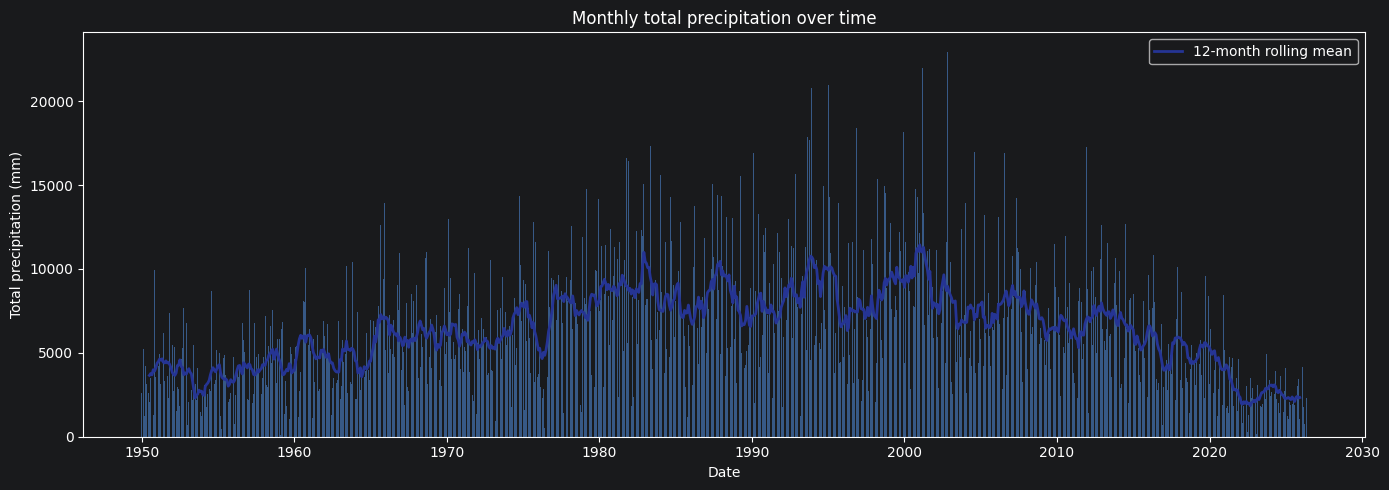

In [92]:
eplots.plot_monthly_precipitation_trend(df)

**P4 — Wind speed by season (violin plot)**

Distribution of daily mean wind speed (`FFM`) across the four seasons.

**Why it matters:** winter winds are stronger (more synoptic depressions), while summer is calmer (anticyclonic). Storms are more frequent in winter, which is the season where speed restrictions and overhead-line damage are most common. The seasonal pattern here should align with seasonal delay patterns in the train dataset.

In [93]:
eplots.plot_seasonal_wind(df)

[plot_seasonal_wind] season or FFM column missing.


**P5 — Station record coverage (top 20)**

Number of daily records per station for the 20 most complete stations.

**Why it matters:** stations with very few records produce unreliable statistics. When joining the weather dataset to train delay data, stations with long and continuous records will produce the most reliable feature values. This chart shows which stations are the most "useful" sources.

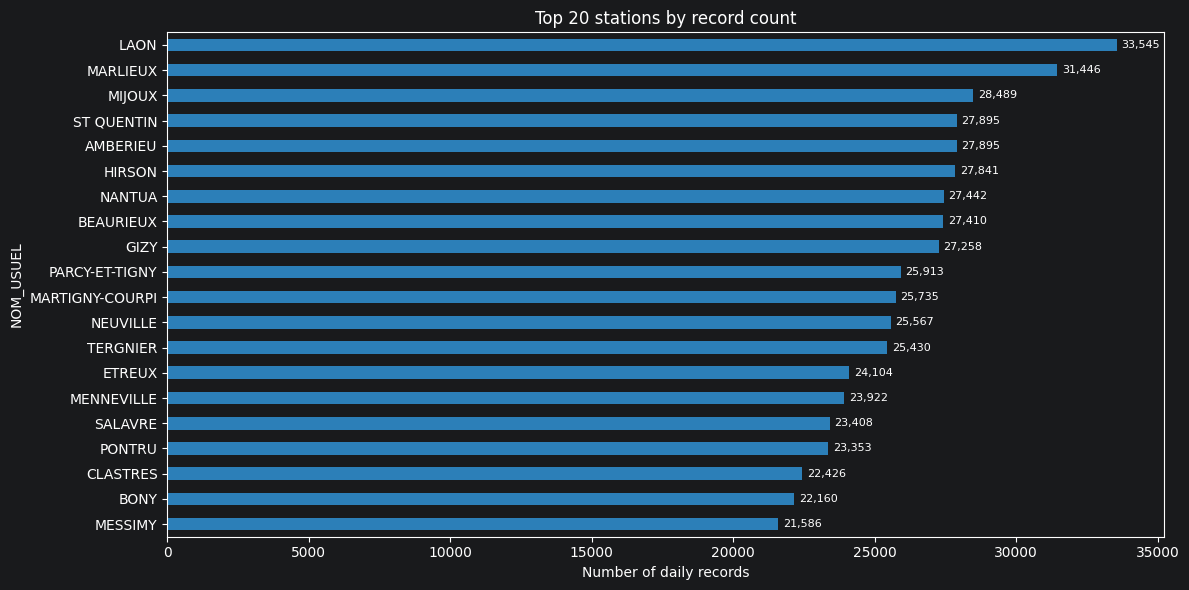

In [94]:
eplots.plot_station_coverage(df)

**P6 — Seasonal statistics heatmap**

A colour-encoded heatmap of mean, median, and standard deviation for temperature (`TM`), precipitation (`RR`), and wind speed (`FFM`) by season. This replaces the plain text table with a visual form that makes cross-season and cross-variable differences immediately apparent.

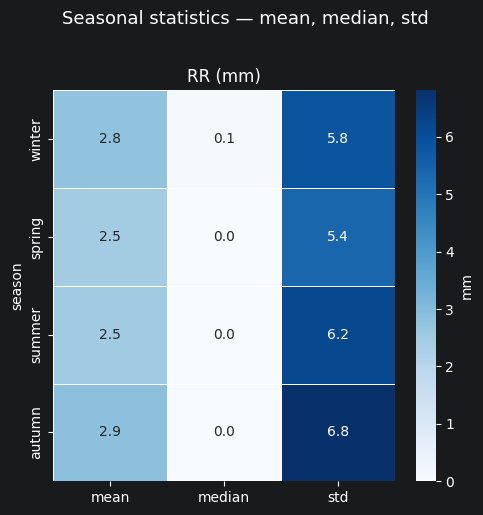

In [95]:
eplots.plot_seasonal_stats_heatmap(df)

---

## Key findings

### What the data shows

| Pattern | Detail |
|---------|--------|
| **Seasonal cycle** | The dominant signal in all variables. Temperature, precipitation frequency, and wind speed all follow a clear 12-month pattern. |
| **Long-term warming** | Visible in the M7 anomaly chart and M13 trend panel — mean temperature has risen since the 1960s–1970s baseline. |
| **Heavy precipitation events** | Right-skewed distribution (M3, M10). Most days are dry; extreme wet days are rare but impactful. |
| **Structural sparsity** | Many sensor columns are present in only a subset of stations. Columns below 60% completeness were removed (section 2.1). |

### What this means for train delay modelling

The cleaned meteorological dataset is ready to be joined to the train punctuality data (`cleaned_dataset.csv`) on a **date × geographic proximity** basis.

The weather features most likely to predict delays:

| Feature | Mechanism |
|---------|-----------|
| `precip_category = heavy` | Track flooding, visibility reduction, signal failures |
| `wind_category = storm` | Speed restrictions, overhead line damage |
| `VERGLAS` (ice on ground) | Adhesion loss, switch failures |
| `NEIG` / `NEIGETOTX` (snow) | Switch blockages, boarding delays |
| `TX > 35 °C` | Rail buckling risk, mandatory speed restrictions |
| `BROU` (fog) | Visibility reduction, approach speed limits |
| `ORAG` (thunderstorm) | Signalling failures, passenger safety stops |